In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

zip_path = "/content/drive/MyDrive/cassava_plnt_disease_roboflow.zip"

print(os.path.exists(zip_path))

True


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/cassava_plnt_disease_roboflow.zip"
extract_path = "/content/"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [4]:
import os
import json
import pandas as pd

# Main dataset folder
DATASET_DIR = "/content/cassava_plnt_disease_roboflow"

# Split folders
splits = ["train", "valid", "test"]

# Image extensions
image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

In [5]:
train_dir = os.path.join(DATASET_DIR, "train")

class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print("Classes found:")
for i, cls in enumerate(class_names):
    print(i, cls)

Classes found:
0 Cassava___bacterial_blight
1 Cassava___brown_streak_disease
2 Cassava___green_mottle
3 Cassava___healthy
4 Cassava___mosaic_disease


In [6]:
label_num_disease = {
    str(i): class_name for i, class_name in enumerate(class_names)
}

disease_label_num = {
    class_name: i for i, class_name in enumerate(class_names)
}

In [7]:
json_path = os.path.join(DATASET_DIR, "label_num_disease.json")

with open(json_path, "w") as f:
    json.dump(label_num_disease, f, indent=4)

print(f"\nSaved: {json_path}")


Saved: /content/cassava_plnt_disease_roboflow/label_num_disease.json


In [8]:
def create_split_csv(split_name):
    split_dir = os.path.join(DATASET_DIR, split_name)
    rows = []

    for class_name in class_names:
        class_dir = os.path.join(split_dir, class_name)

        if not os.path.exists(class_dir):
            print(f"Warning: {class_dir} not found")
            continue

        for img_name in os.listdir(class_dir):
            if img_name.lower().endswith(image_exts):
                img_path = os.path.join(split_name, class_name, img_name)

                rows.append({
                    "image_path": img_path,
                    "disease": class_name,
                    "label": disease_label_num[class_name]
                })

    df = pd.DataFrame(rows)

    csv_path = os.path.join(DATASET_DIR, f"{split_name}.csv")
    df.to_csv(csv_path, index=False)

    print(f"Saved: {csv_path} | Images: {len(df)}")

    return df

In [9]:
train_df = create_split_csv("train")
valid_df = create_split_csv("valid")
test_df = create_split_csv("test")

Saved: /content/cassava_plnt_disease_roboflow/train.csv | Images: 12546
Saved: /content/cassava_plnt_disease_roboflow/valid.csv | Images: 1448
Saved: /content/cassava_plnt_disease_roboflow/test.csv | Images: 1930


In [10]:
print("\nTrain CSV preview:")
display(train_df.head())

print("\nFiles now inside dataset folder:")
print(os.listdir(DATASET_DIR))


Train CSV preview:


,image_path,disease,label
0,train/Cassava___bacterial_blight/2353511211_jp...,Cassava___bacterial_blight,0
1,train/Cassava___bacterial_blight/2652140476_jp...,Cassava___bacterial_blight,0
2,train/Cassava___bacterial_blight/3042546896_jp...,Cassava___bacterial_blight,0
3,train/Cassava___bacterial_blight/1488108256_jp...,Cassava___bacterial_blight,0
4,train/Cassava___bacterial_blight/1124291241_jp...,Cassava___bacterial_blight,0



Files now inside dataset folder:
['README.dataset.txt', 'label_num_disease.json', 'train.csv', 'README.roboflow.txt', 'test.csv', 'valid', 'test', 'valid.csv', 'train']


In [11]:
os.listdir(extract_path)

['.config', 'cassava_plnt_disease_roboflow', 'drive', 'sample_data']

In [20]:
import os
import json
import pandas as pd

import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
DATASET_PATH = "/content/cassava_plnt_disease_roboflow"

In [13]:
train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

In [14]:
train_csv_path = os.path.join(DATASET_PATH, "train.csv")
valid_csv_path = os.path.join(DATASET_PATH, "valid.csv")
test_csv_path  = os.path.join(DATASET_PATH, "test.csv")

In [15]:
label_json_path = os.path.join(DATASET_PATH, "label_num_disease.json")

In [16]:
train_df = pd.read_csv(train_csv_path)
valid_df = pd.read_csv(valid_csv_path)
test_df = pd.read_csv(test_csv_path)

In [17]:
label_json_path = os.path.join(DATASET_PATH, "label_num_disease.json")

with open(label_json_path, "r") as f:
    label_map = json.load(f)

print("Dataset loaded successfully!")
print("Train images folder:", train_dir)
print("Valid images folder:", valid_dir)
print("Test images folder:", test_dir)

print("\nTrain CSV shape:", train_df.shape)
print("Valid CSV shape:", valid_df.shape)
print("Test CSV shape:", test_df.shape)

print("\nTrain CSV columns:")
print(train_df.columns)

print("\nLabel mapping:")
print(label_map)

Dataset loaded successfully!
Train images folder: /content/cassava_plnt_disease_roboflow/train
Valid images folder: /content/cassava_plnt_disease_roboflow/valid
Test images folder: /content/cassava_plnt_disease_roboflow/test

Train CSV shape: (12546, 3)
Valid CSV shape: (1448, 3)
Test CSV shape: (1930, 3)

Train CSV columns:
Index(['image_path', 'disease', 'label'], dtype='object')

Label mapping:
{'0': 'Cassava___bacterial_blight', '1': 'Cassava___brown_streak_disease', '2': 'Cassava___green_mottle', '3': 'Cassava___healthy', '4': 'Cassava___mosaic_disease'}


In [18]:
train_df.head()

,image_path,disease,label
0,train/Cassava___bacterial_blight/2353511211_jp...,Cassava___bacterial_blight,0
1,train/Cassava___bacterial_blight/2652140476_jp...,Cassava___bacterial_blight,0
2,train/Cassava___bacterial_blight/3042546896_jp...,Cassava___bacterial_blight,0
3,train/Cassava___bacterial_blight/1488108256_jp...,Cassava___bacterial_blight,0
4,train/Cassava___bacterial_blight/1124291241_jp...,Cassava___bacterial_blight,0


                            Class  Image_Count
0      Cassava___bacterial_blight         1283
1  Cassava___brown_streak_disease         2715
2          Cassava___green_mottle         2971
3               Cassava___healthy         2748
4        Cassava___mosaic_disease         2829


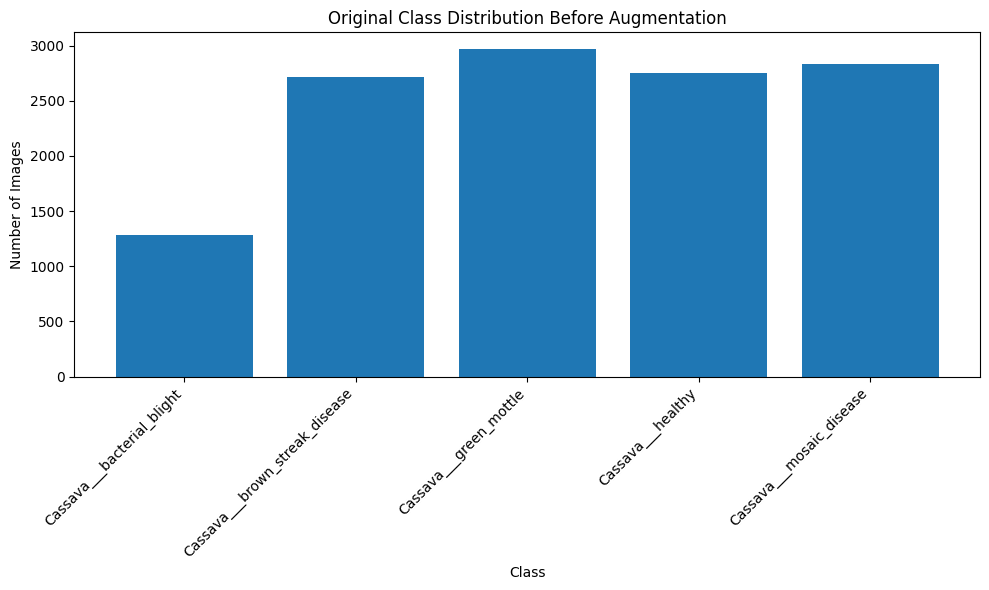

In [21]:
image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for class_name in sorted(os.listdir(train_dir)):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        count = len([
            file for file in os.listdir(class_path)
            if file.lower().endswith(image_exts)
        ])
        class_counts[class_name] = count

df_counts = pd.DataFrame(
    list(class_counts.items()),
    columns=["Class", "Image_Count"]
)

print(df_counts)

plt.figure(figsize=(10, 6))
plt.bar(df_counts["Class"], df_counts["Image_Count"])
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Original Class Distribution Before Augmentation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
classes = df_counts["Class"].values
counts = df_counts["Image_Count"].values

labels = []

for class_name, count in zip(classes, counts):
    labels.extend([class_name] * count)

labels = np.array(labels)

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights_by_name = {
    class_name: weight
    for class_name, weight in zip(np.unique(labels), class_weight_values)
}

df_counts["Class_Weight"] = df_counts["Class"].map(class_weights_by_name)

print(df_counts)

                            Class  Image_Count  Class_Weight
0      Cassava___bacterial_blight         1283      1.955729
1  Cassava___brown_streak_disease         2715      0.924199
2          Cassava___green_mottle         2971      0.844564
3               Cassava___healthy         2748      0.913100
4        Cassava___mosaic_disease         2829      0.886957
